In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter
import csv
from matplotlib.colors import LogNorm

# Import Illustris q(M,z)-distribution

Adapted from Illustris. Happy to provide code for this if necessary.

In [2]:
q_distribution = np.load('q_distribution.npz')

# functions for residence time, lensing duration

In [3]:
G = 6.674e-11
solar_mass = 1.989e30

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

c = 3*10**8
H_0 = 70 
omega_m = 0.3
omega_lambda = 0.7

def luminosity_distance(redshift):
    return cosmo.luminosity_distance(redshift).value

def i_magnitude(redshift, total_mass):
    dL_z = luminosity_distance(redshift)
    dL_2 = luminosity_distance(2)
    mass_convert = total_mass/(3*10**6)
    f_edd = 0.3
    i_mag = 24 + 2.5 * np.log10(1/(mass_convert)*(dL_z/dL_2)**2 * (f_edd / 0.3)**-1)
    return i_mag   
def lifetime(q, M, T, z):
    A = 1.7 * 10**7
    B = 4.4 * 10**7
    q_s = (4*q/(1+q)**2)
    M_7 = M/(10**7)
    lifetime = (1.11 * 10**7) * q_s**-1 * M_7**(-5/3) * T**(8/3) * (1 + z)
    tp = turning_point(q,M,T,z)
    result = np.where(lifetime < A, lifetime, (A + B * (T - tp)))
    return result

def turning_point(q, M, T, z):
    A = 1.7 * 10**7
    q_s = (4*q/(1+q)**2)
    M_7 = M/(10**7)
    return (A * M_7 ** (5/3) * q_s / ((1+z)*(1.11 * 10**7)))**(3/8)

def lifetime2(q, M, T, z):
    A = 1.7 * 10**7
    B = 4.4 * 10**7
    q_s = (4*q/(1+q)**2)
    M_7 = M/(10**7)
    lifetime = (1.11 * 10**7) * q_s**-1 * M_7**(-5/3) * T**(8/3) * (1 + z)
    tp = turning_point(q,M,T,z)
    #result = np.where(lifetime < A, lifetime, (A + B * (T - tp)))
    result = np.where(lifetime < A, lifetime, A)
    return result

def lifetime3(q, M, T, z):
    q_s = (4*q/(1+q)**2)
    M_7 = M/(10**7)
    lifetime = (1.11 * 10**7) * q_s**-1 * M_7**(-5/3) * (T)**(8/3) * (1 + z)
    return lifetime

def einstein_radius(q, M, T, z):
    T_s = T * 365.25 * 24 * 3600 / (1 + z)  # seconds
    M_g = M * 1.989e33
    Mp = M / (1 + q) * 1.989e33  # Mass of larger object
    a = ((G * M_g * T_s**2) / (4 * np.pi**2))**(1/3)
    return np.sqrt(4 * a * G * Mp / c**2)

def lensing_duration(q, M, T, z):
    T_s = T * 365.25 * 24 * 3600 / (1+z)  # seconds
    M_g = M * 1.989e33
    G = 6.674e-8
    c = 3 * 10**10
    a = ((G * M_g * T_s**2) / (4 * np.pi**2))**(1/3)
    T_d = T * 365  # days
    return T_d * (np.arcsin(einstein_radius(q, M, T, z) / a)) / np.pi

# def lensing_duration_cutoff(q, M, T, z):
#     T_s = T * 365.25 * 24 * 3600 / (1+z)  # seconds
#     M_g = M * 1.989e33
#     G = 6.674e-8
#     c = 3 * 10**10
#     a = ((G * M_g * T_s**2) / (4 * np.pi**2))**(1/3)
#     T_d = T * 365  # days
#     er = einstein_radius(q, M, T, z)
#     ld = T_d * (np.arcsin(er / a)) / np.pi
#     return ld > 30


  # Example access for T=0 and q=0


# Importing or Generating Lensing Cutoffs

For excluding lensing events that are shorter than 10, 20 or 30 days

In [6]:
def lensing_duration_cut(q, M, T, z):
    T_s = T * 365.25 * 24 * 3600 / (1 + z)  
    M_g = M * 1.989e33 
    G = 6.674e-8  
    c = 3 * 10**10  
    a = ((G * M_g * T_s**2) / (4 * np.pi**2))**(1/3)
    ein_radius = einstein_radius(q, M, T, z) 
    T_d = T * 365.25  
    arcsin_arg = np.clip(ein_radius / a, -1, 1)  
    ld = T_d * (np.arcsin(arcsin_arg)) / np.pi 
    
    if np.isscalar(ld):
        return 1 if ld > 0 else 0
    else:
        return 1 if np.any(ld > 0) else 0
        
redshift = np.linspace(0, 6, 50)
total_mass = np.logspace(5, 9.5, 50)
period_array = np.linspace(0, 5, num=50) 

# ld_cutoff = np.zeros((len(period_array), 7, len(total_mass), len(redshift)))

# for i, T in enumerate(period_array):
#     for q in range(7):
#         q_avg = 10**(-0.25 - 0.5 * q)
#         for j, M in enumerate(total_mass):
#             for k, z in enumerate(redshift):
#                 # Print inputs for debugging
#                 print(f"Computing ld_cutoff for T={T}, q_avg={q_avg}, M={M}, z={z}")
#                 ld_cutoff[i, q, j, k] = lensing_duration_cut(q_avg, M, T, z)
#                 # Print output for debugging
#                 print(f"ld_cutoff[{i}, {q}, {j}, {k}] = {ld_cutoff[i, q, j, k]}")


# # Save ld_cutoff to an .npz file
# np.savez('ld_cutoff_0.npz', ld_cutoff=ld_cutoff)

data_30 = np.load('ld_cutoff_30.npz')
ld_cutoff_30 = data_30['ld_cutoff']

data_20 = np.load('ld_cutoff_20.npz')
ld_cutoff_20 = data_20['ld_cutoff']

data_10 = np.load('ld_cutoff_10.npz')
ld_cutoff_10 = data_10['ld_cutoff']

data_0 = np.load('ld_cutoff_0.npz')
ld_cutoff_0 = data_0['ld_cutoff']


# Load QLF

exclude quasars with magnitude cutoffs of 24-26 for LSST, you should vary for PLATO

/var/folders/nc/vpj3jx516wbfyb_vfccc7gph0000gn/T/ipykernel_37484/1523993821.py:21: RuntimeWarning: divide by zero encountered in log10
  i_mag = 24 + 2.5 * np.log10(1/(mass_convert)*(dL_z/dL_2)**2 * (f_edd / 0.3)**-1)


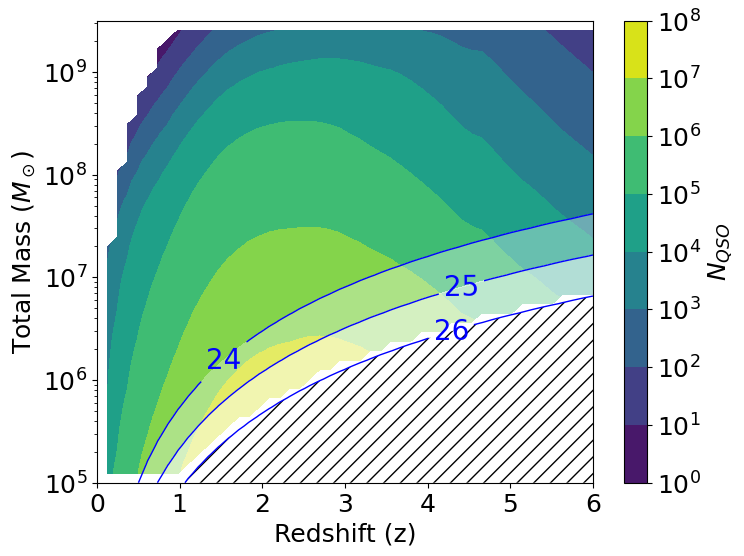

In [13]:
from scipy.interpolate import griddata
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, LogFormatter

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 18})

mass_data = pd.read_csv('N_QSO', delim_whitespace=True)
mass_data.columns = ['log_M', 'z', 'N_QSO']

mass_data['M'] = 10**mass_data['log_M']

mass_data = mass_data[(mass_data['log_M'] >= 5) & (mass_data['log_M'] <= 9.5)]

i_mags = i_magnitude(mass_data['z'].values, mass_data['M'].values)

#####Where to implement Plato magnitude cutoffs########
magnitude_cutoff = 26
########################################################
mass_data['N_QSO'] = np.where(i_mags > magnitude_cutoff, np.nan, mass_data['N_QSO'])

redshift = np.linspace(0, 6, 50)
total_mass = np.logspace(5, 9.5, 50)
redshift, total_mass = np.meshgrid(redshift, total_mass)

N_QSO = griddata((mass_data['z'], mass_data['log_M']), mass_data['N_QSO'], (redshift, np.log10(total_mass)), method='linear')

contour = plt.contourf(redshift,(total_mass), N_QSO, levels=[10**0,10**1,10**2,10**3,10**4,10**5,10**6,10**7,10**8], cmap='viridis', norm=LogNorm())
colorbar = plt.colorbar(contour)
colorbar.set_label(r'$N_{QSO}$')

contour_LSST_1 = plt.contourf(redshift, total_mass, i_magnitude(redshift, total_mass), levels=[24, 25], colors='white', alpha = 0.33)
contour_LSST_2 = plt.contourf(redshift, total_mass, i_magnitude(redshift, total_mass), levels=[25, 26], colors='white', alpha = 0.66)
contour_LSST_3 = plt.contourf(redshift, total_mass, i_magnitude(redshift, total_mass), levels=[26, 32], colors='none', hatches=['//'])

hatch_contour_1 = plt.contour(redshift, total_mass, i_magnitude(redshift, total_mass), levels=[24, 25, 26], colors='blue', linestyles='solid', linewidths=1)
plt.clabel(hatch_contour_1, inline=True, fontsize=20)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Total Mass ($M_\odot$)')
plt.yscale('log')
# plt.savefig('N_QSO.pdf', format='pdf')

plt.show()


# Number of Point Source Flares

In [14]:
n_flares = 0
n_flares_mz = np.zeros((50, 50))
P_point = np.load('P_point.npy')
n_flares_T = []

for T in range(10):
    for q in range(7):
        avg_mass_ratio=10**(-0.25 + q * (-0.5))
        n1 = q_distribution['arr_0'][q] * P_point[q][T] * N_QSO * ld_cutoff_0[5 * T + 4][q] * lifetime(avg_mass_ratio, total_mass, 0.5 + T/2, redshift) / 10**8
        n2 = q_distribution['arr_0'][q] * P_point[q][T] * N_QSO * ld_cutoff_0[5 * T + 4][q] * lifetime(avg_mass_ratio, total_mass, T/2, redshift) / 10**8
        delta_n = (n1 - n2)
        positive_mask = (delta_n > 0) & ~np.isnan(delta_n)
        n_flares += np.nansum(delta_n * positive_mask)
        n_flares_mz += delta_n * positive_mask
print(n_flares)

183959.32715389138


#  Number of Finite Source Flares

You'll find that the numbers produced are not precisely the numbers reported on the paper because I was messing around with various integration steps / binning at various stages to see if it was necessary to make more precise 

In [15]:
P_finite = np.load('P_finite_u_band.npy')

print(P_finite.shape)

(8, 10, 50, 50)


In [16]:
n_finite = 0
n_finite_mz = np.zeros((50, 50))

for T in range(10): #integration over orbital period
    for q in range(7): #integration over mass ratio
        avg_mass_ratio=10**(-0.25 + q * (-0.5))
        n1 = q_distribution['arr_0'][q] * P_finite[q][T] * N_QSO * ld_cutoff_10[5 * T + 4][q] * lifetime(avg_mass_ratio, total_mass, (T+1)/2, redshift) / 10**8
        n2 = q_distribution['arr_0'][q] * P_finite[q][T] * N_QSO * ld_cutoff_10[5 * T + 4][q] * lifetime(avg_mass_ratio, total_mass, T/2, redshift) / 10**8
        delta_n = (n1 - n2)
        positive_mask = (delta_n > 0) & ~np.isnan(delta_n)
        n_finite += np.nansum(delta_n * positive_mask)
  
print(n_finite)

50339.70056172956


# Generating P_Point (probability for point-source flare)

-Calculating the orbital inclination for which peak magnification exceeds 1.1, divide that by 90 degrees to get probability. Finite-source calculation is in other notebook

In [ ]:
from scipy import optimize

def Magn(u):
    return (u**2 + 2)/(u * np.sqrt(u**2+4))

def u2(q, M, T, z, i):
    T_s = T * 365 * 24 * 3600 / (1+z)
    M_g = M * 1.989e33
    G = 6.674e-8
    c = 3 * 10**10
    a = ((G * M_g * T_s**2) / (4 * np.pi**2))**(1/3)
    m1 = q * M_g / (1 + q)
    m2 = M_g - m1
    u2 = np.sqrt(a * c**2 * (np.sin(i))**2 / (4 * G * m2 * np.cos(i)))
    return u2
    
redshift = np.linspace(0, 6, 50)
total_mass = np.logspace(5, 9.5, 50)

P_point = []

for q in range(8):    
    for T in range(10):
        def f(I, T, M, z):
            
            q_input = 10**(-0.25 * (2 * q)-0.25)
            return Magn(u2(q_input, M, T, z, I)) - 1.1
        
        for M in total_mass:
            for Z in redshift:
                try:
                    sol = optimize.root_scalar(f, args=(T, M, Z), bracket=[0.00000001, 1], method='brentq')
                    I = sol.root
                    P_point.append(np.degrees(I)/90)
                except ValueError:
                    P_point.append(0)

P_point = np.array(P_point).reshape(8, 10, 50, 50)
# np.save('P_point.npy', P_point)